In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
housing = pd.read_csv("Housing.csv")

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [20]:
print("Dataset Shape :", housing.shape)

housing.info()

housing.describe()

Dataset Shape : (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [21]:
housing.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [22]:
cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

housing[cols] = housing[cols].replace({
    "yes": 1,
    "no": 0
})

housing = pd.get_dummies(
    housing,
    columns=["furnishingstatus"],
    drop_first=True
)

housing.head()

/var/folders/xf/w7vpz9rj451_yy82z6tjc9000000gn/T/ipykernel_6656/91346946.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  housing[cols] = housing[cols].replace({


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [23]:
features = housing.drop(columns=["price"])

target = housing["price"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42
)

In [25]:
std_scaler = StandardScaler()

X_train = std_scaler.fit_transform(X_train)

X_test = std_scaler.transform(X_test)

In [26]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1)
])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25349394006016.0000 - mae: 4727422.5000 - val_loss: 24781602684928.0000 - val_mae: 4623897.5000
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25349389811712.0000 - mae: 4727422.0000 - val_loss: 24781598490624.0000 - val_mae: 4623897.5000
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25349387714560.0000 - mae: 4727422.0000 - val_loss: 24781594296320.0000 - val_mae: 4623896.5000
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 25349379325952.0000 - mae: 4727421.5000 - val_loss: 24781583810560.0000 - val_mae: 4623896.0000
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - loss: 25349366743040.0000 - mae: 4727419.5000 - val_loss: 24781564936192.0000 - val_mae: 4623894.0000
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 25349343674368.0000 - mae: 4727416.5000 - val_loss: 24781533478912.0000 - val_mae: 4623891.5000
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - loss: 253

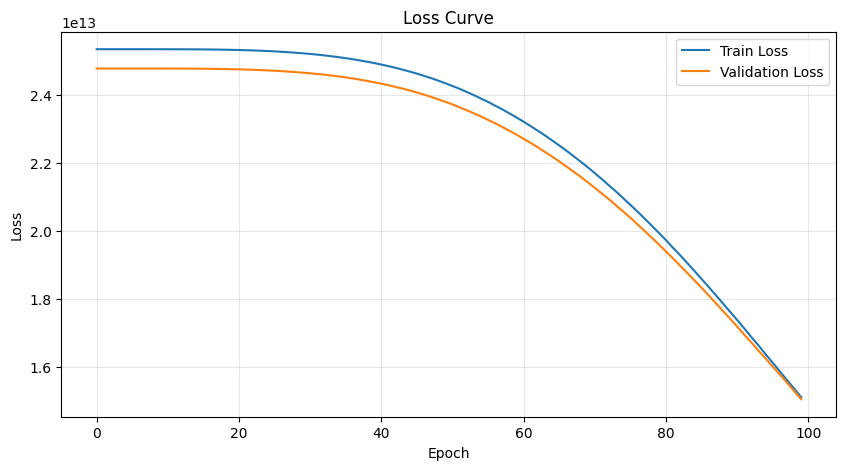

In [30]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [31]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print(f"Test Loss : {test_loss}")

print(f"Test MAE : {test_mae}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17985257340928.0000 - mae: 3962793.5000 
Test Loss : 17985257340928.0
Test MAE : 3962793.5


In [32]:
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [33]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 3962792.75
Root Mean Squared Error : 4240902.644930204
R2 Score : -2.5582163333892822


In [34]:
comparison = pd.DataFrame({
    "Actual Price": y_test.to_numpy(),
    "Predicted Price": predictions.ravel()
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,9.894746e+04
1,6650000,2.366874e+06
2,3710000,2.953248e+05
3,6440000,7.824379e+05
4,2800000,1.595703e+05
5,4900000,1.192839e+05
6,5250000,1.551140e+06
7,4543000,2.469239e+06
8,2450000,8.802948e+04
9,3353000,1.204840e+05


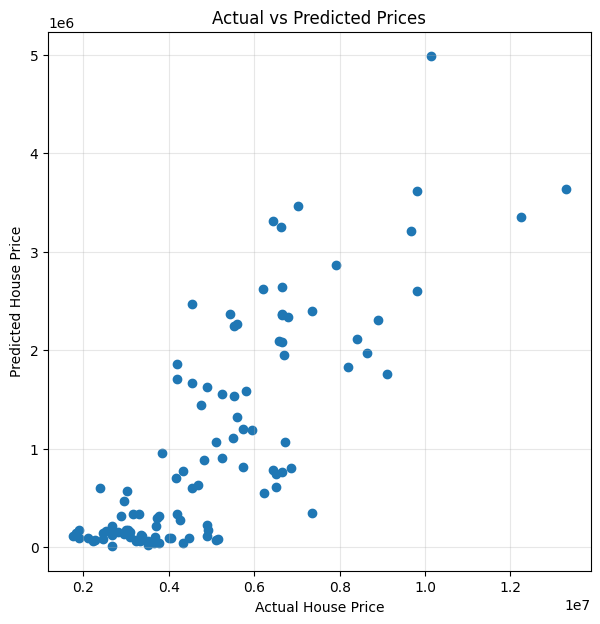

In [35]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted Prices")

plt.grid(alpha=0.3)

plt.show()